# Studying the initial neutron star population

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import rc
import matplotlib as mpl

# Set `usetex=False' if you do not have LaTeX installed.
rc('text', usetex=True)
rc('font', family='serif')
mpl.rcParams['text.latex.preamble'] = [r"\usepackage{amsmath}"]

In [2]:
rcParams["mathtext.fontset"] = "stix"
# rcParams["font.family"] = "Liberation serif"
rcParams["font.size"] = "25"
# rcParams['font.weight']='bold'
rcParams["figure.figsize"] = "8.0, 8.0"
rcParams["figure.autolayout"] = "False"

rcParams["axes.linewidth"] = "1.7"
rcParams["axes.labelpad"] = "15.0"
rcParams["axes.titlepad"] = "15.0"

rcParams["xtick.direction"] = "in"
rcParams["xtick.top"] = True
rcParams["xtick.major.pad"] = "10.0"
rcParams["xtick.minor.pad"] = "10.0"
rcParams["xtick.major.size"] = "10.0"
rcParams["xtick.major.width"] = "1.7"
rcParams["xtick.minor.size"] = "5.0"
rcParams["xtick.minor.width"] = "1.7"
rcParams["xtick.labelsize"] = "25"

rcParams["ytick.direction"] = "in"
rcParams["ytick.right"] = True
rcParams["ytick.major.pad"] = "10.0"
rcParams["ytick.minor.pad"] = "10.0"
rcParams["ytick.major.size"] = "10.0"
rcParams["ytick.major.width"] = "1.7"
rcParams["ytick.minor.size"] = "5.0"
rcParams["ytick.minor.width"] = "1.7"
rcParams["ytick.labelsize"] = "25"

Select an `initial_population.txt` file to import:

In [3]:
data = pd.read_csv("../data/initial_population.txt", header=[0,1])
data.head()

,age,r,phi,x,y,z,v_r,v_phi,v_z,vp_r,vp_phi,vp_z,v_orb
,[yr],[kpc],[rad],[kpc],[kpc],[kpc],[kpc / yr],[kpc / yr],[kpc / yr],[kpc / yr],[kpc / yr],[kpc / yr],[kpc / yr]
0,4.129277e+07,6.505138,8.522313,-4.031088,5.105600,-0.508012,-8.930296e-07,-1.693685e-07,3.358557e-07,-8.930296e-07,5.574640e-08,3.358557e-07,-2.251149e-07
1,8.491184e+07,10.300069,11.160556,1.691627,-10.160208,-0.076719,-1.767947e-07,-2.607958e-07,7.700749e-08,-1.767947e-07,-3.969783e-08,7.700749e-08,-2.210980e-07
2,2.312859e+07,2.594246,3.073432,-2.588223,0.176687,0.145836,3.533427e-07,-2.045540e-07,-6.028758e-07,3.533427e-07,1.267008e-09,-6.028758e-07,-2.058210e-07
3,1.649500e+07,15.421233,6.394564,15.325681,1.714045,-0.030485,5.913711e-07,-3.207169e-07,1.490871e-07,5.913711e-07,-1.212287e-07,1.490871e-07,-1.994882e-07
4,5.284807e+07,1.912337,-0.424070,1.742945,-0.786876,-0.066906,2.237556e-07,-2.839781e-07,-2.429179e-07,2.237556e-07,-7.869930e-08,-2.429179e-07,-2.052788e-07


In [4]:
age = data["age"]["[yr]"].to_numpy()
r = data["r"]["[kpc]"].to_numpy()
phi = data["phi"]["[rad]"].to_numpy()
x = data["x"]["[kpc]"].to_numpy()
y = data["y"]["[kpc]"].to_numpy()
z = data["z"]["[kpc]"].to_numpy()
v_r = data["v_r"]["[kpc / yr]"].to_numpy()
v_phi = data["v_phi"]["[kpc / yr]"].to_numpy()
v_z = data["v_z"]["[kpc / yr]"].to_numpy()
v_proper_r = data["vp_r"]["[kpc / yr]"].to_numpy()
v_proper_phi = data["vp_phi"]["[kpc / yr]"].to_numpy()
v_proper_z = data["vp_z"]["[kpc / yr]"].to_numpy()
v_orb = data["v_orb"]["[kpc / yr]"].to_numpy()

Top view of the galactic plane

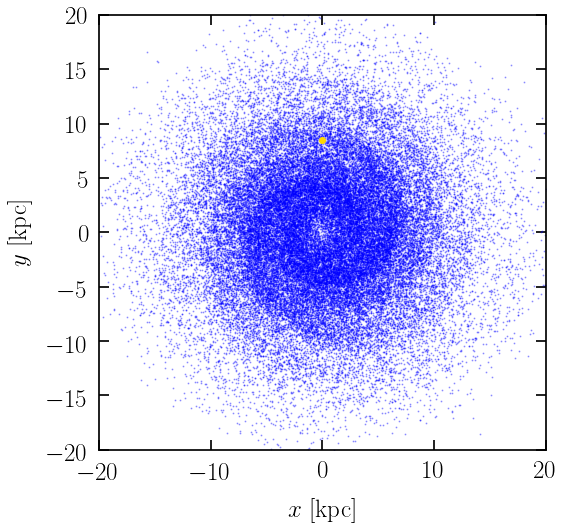

In [5]:
fig, ax = plt.subplots()

ax.plot(
    x,
    y,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=False
)

ax.plot(0.0, 8.5, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$y$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Side view of the galactic plane

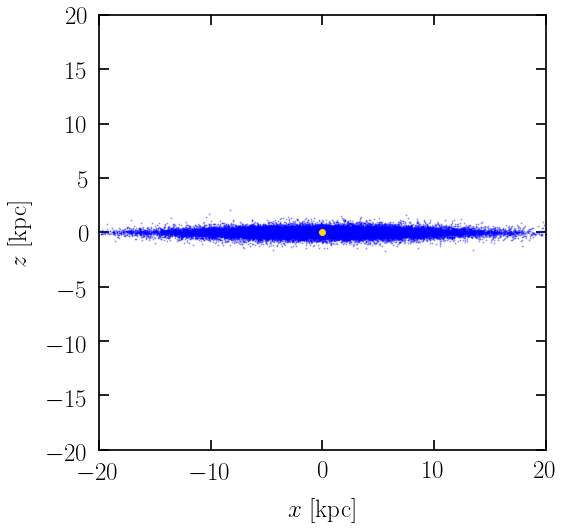

In [6]:
fig, ax = plt.subplots()

ax.plot(
    x,
    z,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.plot(0.0, 0.02, marker="o", color="gold", markersize=6)
ax.set_xlabel(r"$x$ [kpc]")
ax.set_ylabel(r"$z$ [kpc]")
ax.set_xlim(-20.0, 20.0)
ax.set_ylim(-20.0, 20.0)

plt.show()

Histogrammed proper velocity components

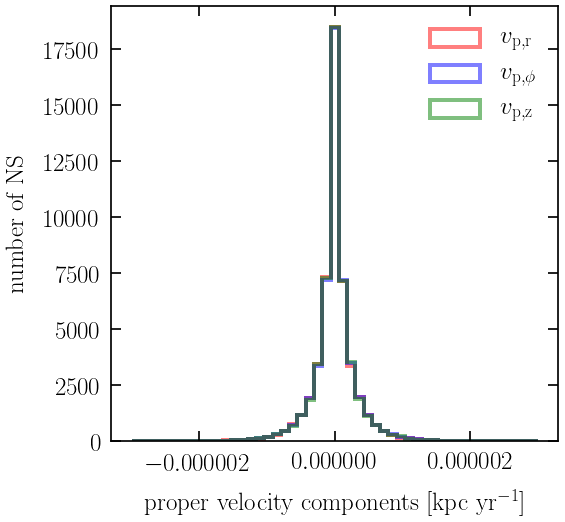

In [7]:
fig, ax = plt.subplots()
# x_bins = np.linspace(-2000.,2000.,50)  # bins for velocity in km / s
x_bins = np.linspace(-3.0e-6, 3.0e-6, 50)

ax.hist(
    v_proper_r,
    bins=x_bins,
    histtype="step",
    edgecolor="red",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}r}$",
)
ax.hist(
    v_proper_phi,
    bins=x_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}\phi}$",
)
ax.hist(
    v_proper_z,
    bins=x_bins,
    histtype="step",
    edgecolor="green",
    lw=4,
    alpha=0.5,
    label=r"$v_{\rm{p,}z}$",
)
ax.set_xlabel(r"proper velocity components [kpc yr$^{-1}$]")
ax.set_ylabel(r"number of NS")
plt.legend(frameon=False, loc=0)

plt.show()

Orbital (angular) velocity due to galactic potential

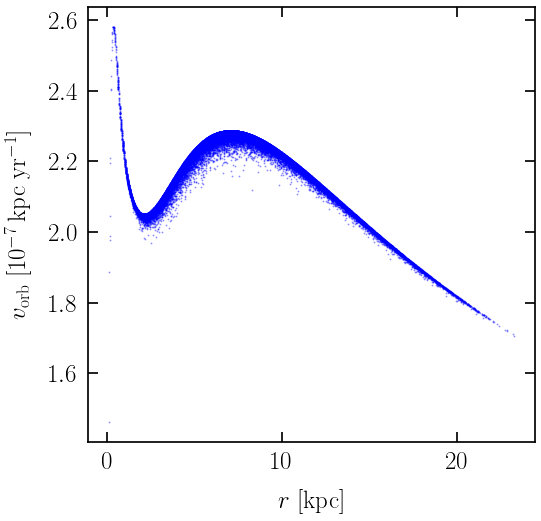

In [8]:
fig, ax = plt.subplots()

ax.plot(
    r,
    abs(v_orb) * 1e7,
    linestyle="None",
    marker="o",
    color="blue",
    markersize=1,
    alpha=0.3,
    rasterized=True,
)

ax.set_xlabel(r"$r$ [kpc]")
ax.set_ylabel(r"$v_{\rm orb}$ [$10^{-7} \, $kpc yr$^{-1}$]")

plt.show()

Histrogramming the pulsars position and comparing to underlying PDF

In [9]:
def pdf_r(r):
    "pdf from the Milky Way stellar surface density (Yusifov & Küçük 2004)"
    A = 37.6  # [stars kpc^-2]
    R1 = 0.55  # +-0.1 [kpc]
    Rsun = 8.5
    a = 1.64  # +-0.11
    b = 4.01  # +-0.24
    rho = (
        A
        * ((r + R1) / (Rsun + R1)) ** a
        * np.exp(-b * ((r - Rsun) / (Rsun + R1)))
    )
    pdf_r = 2 * np.pi * r * rho
    return pdf_r

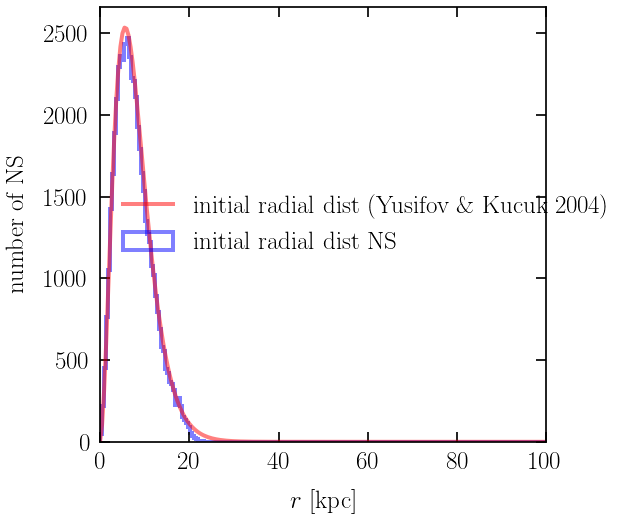

In [10]:
# r_bins = np.logspace(np.log10(0.0001), np.log10(100.), 100)
r_bins = np.linspace(0.0, 100.0, 220)

fig, ax = plt.subplots()

ax.hist(
    r,
    bins=r_bins,
    histtype="step",
    edgecolor="blue",
    lw=4,
    alpha=0.5,
    label="initial radial dist NS",
)
ax.plot(
    r_bins,
    pdf_r(r_bins),
    linestyle="-",
    lw=4,
    color="red",
    alpha=0.5,
    label="initial radial dist (Yusifov \& Kucuk 2004)",
)
plt.xlabel(r"$r$ [kpc]")
plt.ylabel(r"number of NS")
plt.xlim(0.0, 100.0)
plt.legend(frameon=False, loc=0)

plt.show()